# ML-06 — Signal Audit: Do the Flags Hold?

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/rudrabansal10/FlyRank_Internship/blob/main/work/notebooks/w04_signal_audit.ipynb)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

In [1]:
import pandas as pd

df = pd.read_csv("https://raw.githubusercontent.com/rudrabansal10/FlyRank_Internship/43b468d73eba109085f02d01f3a59754d5356453/data/raw/content_refresh_anonymized.csv")

In [2]:
df["is_declining_label"] = (df["trend_direction"] == "down").astype(int)

## 1. Distributions

*Look before deciding: distributions of your key fields. Note the heavy tails.*

,impressions_90d,clicks_90d,sessions_90d,days_since_last_update,word_count,ctr,avg_position
count,30000.000000,30000.000000,30000.000000,30000.000000,22301.000000,30000.000000,30000.00000
mean,5200.366300,16.097333,37.066633,46.098300,3107.760325,0.510733,16.34238
std,16838.019547,75.076958,107.069131,42.078709,1452.382598,3.279162,15.21679
min,1.000000,0.000000,1.000000,1.000000,8.000000,0.000000,0.00000
25%,81.000000,0.000000,2.000000,20.000000,2413.000000,0.000000,6.20000
50%,731.000000,1.000000,7.000000,20.000000,2877.000000,0.070000,10.80000
75%,3615.250000,7.000000,27.000000,104.000000,3666.000000,0.290000,22.30000
max,517715.000000,4178.000000,4345.000000,373.000000,9546.000000,100.000000,245.00000


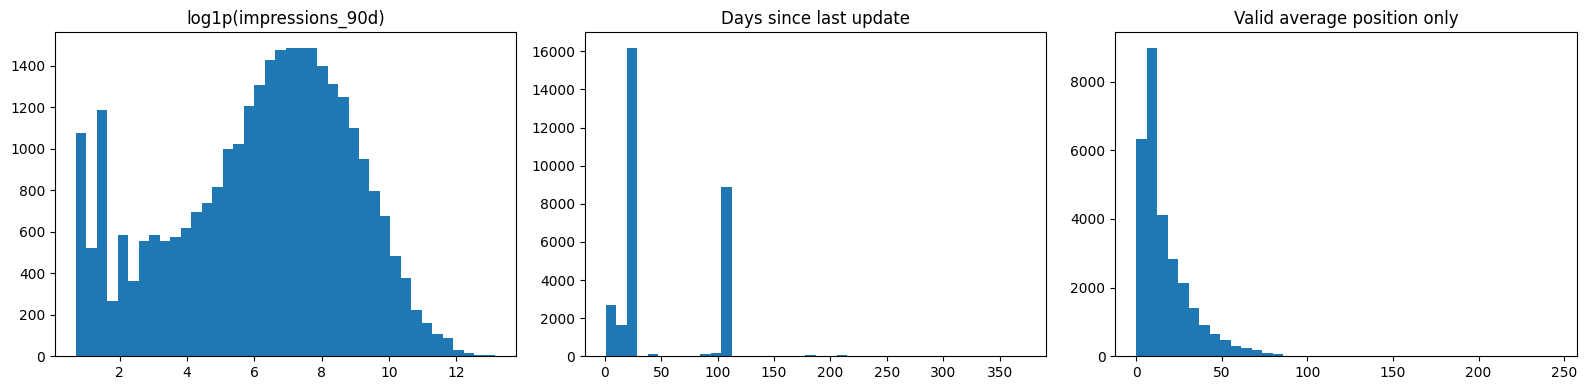

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

key_columns = [
    "impressions_90d",
    "clicks_90d",
    "sessions_90d",
    "days_since_last_update",
    "word_count",
    "ctr",
    "avg_position",
]

display(df[key_columns].describe())

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(np.log1p(df["impressions_90d"]), bins=40)
axes[0].set_title("log1p(impressions_90d)")

axes[1].hist(df["days_since_last_update"], bins=40)
axes[1].set_title("Days since last update")

axes[2].hist(df.loc[df["avg_position"] > 0, "avg_position"], bins=40)
axes[2].set_title("Valid average position only")

plt.tight_layout()
plt.show()

Traffic variables are heavily right-skewed: a small number of pages receive much more traffic than most pages. I therefore use traffic bands or log-scaled views rather than raw averages. avg_position = 0 is treated as unavailable position data, not a top rankin

## 2. Signal test #1 / #2 / #3 (verdict each)

*Three safe signals, each with a mini-test and a verdict: CONFIRMED / OPPOSITE / MIXED / FALSE.*

Signal test #1 — freshness

Claim: “Older pages may have a higher observed decline rate.”

In [9]:
freshness = df.copy()

freshness["freshness_band"] = pd.cut(
    freshness["days_since_last_update"],
    bins=[-1, 90, 180, 365, np.inf],
    labels=["0–90", "91–180", "181–365", "366+"],
)

freshness_result = (
    freshness.groupby("freshness_band", observed=False)
    .agg(
        pages=("content_id", "size"),
        declining_rate=("is_declining_label", "mean"),
        median_impressions=("impressions_90d", "median"),
    )
    .reset_index()
)

display(freshness_result)

,freshness_band,pages,declining_rate,median_impressions
0,0–90,20655,0.512031,472.0
1,91–180,9171,0.611057,1692.0
2,181–365,169,0.467456,16.0
3,366+,5,0.600000,2.0


Verdict - FALSE

Signal test #2 — content depth

Claim: “Shorter pages may show more observed decline.”

In [10]:
depth = df[df["word_count"].notna()].copy()

depth["word_count_band"] = pd.cut(
    depth["word_count"],
    bins=[-1, 800, 1200, 2000, np.inf],
    labels=["0–800", "801–1200", "1201–2000", "2001+"],
)

depth_result = (
    depth.groupby("word_count_band", observed=False)
    .agg(
        pages=("content_id", "size"),
        declining_rate=("is_declining_label", "mean"),
        median_impressions=("impressions_90d", "median"),
    )
    .reset_index()
)

display(depth_result)

,word_count_band,pages,declining_rate,median_impressions
0,0–800,322,0.208075,3.0
1,801–1200,975,0.263590,6.0
2,1201–2000,3457,0.571883,215.0
3,2001+,17547,0.591440,1094.0


Verdict - OPPOSITE

Signal test #3 — low CTR with visible positions

Claim: “Visible pages with CTR below 0.5% may deserve review priority.”

In [11]:
ctr_slice = df[
    (df["impressions_90d"] >= 500)
    & (df["avg_position"] > 0)
    & (df["avg_position"] <= 20)
].copy()

ctr_slice["ctr_band"] = np.where(
    ctr_slice["ctr"] < 0.5,
    "CTR below 0.5%",
    "CTR at least 0.5%",
)

ctr_result = (
    ctr_slice.groupby("ctr_band")
    .agg(
        pages=("content_id", "size"),
        declining_rate=("is_declining_label", "mean"),
        median_impressions=("impressions_90d", "median"),
        median_position=("avg_position", "median"),
    )
    .reset_index()
)

display(ctr_result)

,ctr_band,pages,declining_rate,median_impressions,median_position
0,CTR at least 0.5%,2264,0.475265,4729.5,7.2
1,CTR below 0.5%,9759,0.627113,3017.0,8.4


Verdict - CONFIRMED

## 3. The flag-linked test

*Pick a signal one of FlyRank's real flags relies on. Does the data support the rule's assumption?*

This tests the assumption behind the reference rule stale_visible_page.

In [12]:
flag_test = df.copy()

flag_test["stale_visible_flag"] = np.where(
    (flag_test["days_since_last_update"] >= 180)
    & (flag_test["impressions_90d"] >= 500),
    "stale and visible",
    "all other pages",
)

flag_result = (
    flag_test.groupby("stale_visible_flag")
    .agg(
        pages=("content_id", "size"),
        declining_rate=("is_declining_label", "mean"),
        median_impressions=("impressions_90d", "median"),
        median_days_since_update=("days_since_last_update", "median"),
    )
    .reset_index()
)

display(flag_result)

,stale_visible_flag,pages,declining_rate,median_impressions,median_days_since_update
0,all other pages,29983,0.541840,731.0,20.0
1,stale and visible,17,0.941176,4429.0,194.0


The stale-and-visible rule selected 17 pages, of which 94.1% were labelled as declining, compared with 54.2% among other pages. The difference is large, but the flagged group is too small to support a robust conclusion. This rule may be worth retaining as a review signal, but its threshold should be tested with a broader definition or on the full warehouse data.

## 4. What this means in practice

*Two or three sentences: what a content team should take from this.*

The audit found that freshness was not a useful proxy-decline signal in this starter dataset, so it should not receive strong weight in the review score. Content depth showed the opposite of the expected pattern, suggesting that short pages are not automatically the strongest refresh candidates and that word count should be interpreted alongside page type and visibility. Low CTR among visible pages with valid positions was confirmed as a useful review signal, so it can be included in the baseline with clear reason codes. The stale-and-visible rule showed a large directional difference but had only 17 pages, so it needs more data before it can be treated as reliable.

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.